In [1]:
import matplotlib.pyplot as plt
import numpy as np
from distributions import lognormal, normal
from models import owens_bozic_model
from noise_funcs import proportional_normal_noise
from pipeline_utils import generate_ground_truths
from samplers import independent_sampler
from schedulers import uniform_scheduler

NameError: name 'FloatArr' is not defined

In [ ]:
"""
Probably should've clarified that in my table, for lognormal variables,
"standard deviation" in my table is the same as the shape parameter that
scipy.stats.lognorm uses
"""

# a (tumor growth rate)
a_dist = lambda: lognormal(0.2, 0.5, high=0.6)

# 1/b (tumor carrying capacity)
# roughly using values from https://www.nature.com/articles/s41586-019-1252-x
b_dist = lambda: 1 / lognormal(1.37e11, 1.14, high=1e13)

# dE (max killing rate of effector T cells)
dE_dist = lambda: lognormal(2.22, 0.34)

# dC (max killing rate of CAR T_cells)
dC_dist = lambda: 2.25

# g (endogenous effector cell source term)
g_dist = lambda: 1.03e4

# jE (effector cell recruitment rate)
jE_dist = lambda: 1.56e-2

# jC (CAR T-cell recruitment rate)
jC_dist = lambda: lognormal(3.46e-1, 0.75)

# K (joint effector cell carrying capacity)
K_dist = lambda: 5.21e8

# k (steepness of effector cell recruitment curve)
k_dist = lambda: 8.67e6

# l (exponent of tumor lysis by effector cells)
l_dist = lambda: lognormal(1.418, 0.15)

# mE (death rate of effector cells)
mE_dist = lambda: 1.7e-2

# mC (death rate of CAR T-cells)
mC_dist = lambda: 2.93e-2

# qE (effector cell exhaustion)
qE_dist = lambda: lognormal(1.28e-10, 1.35)

# qC (CAR T-cell exhaustion)
qC_dist = lambda: lognormal(2.14e-10, 2.6)

# s (effector to CAR T-cell ratio for half maximual lysis)
s_dist = lambda: lognormal(0.302, 0.17, high=1)

KT_dist = lambda: 7e-1

KE_dist = lambda: 6e-1

KC_dist = lambda: 6e-1

gamma_dist = lambda: 9e-1

T0_dist = lambda: lognormal(1.58e9, 1.5)
E0_dist = lambda: 4e5
C0_dist = lambda: lognormal(6.3e7, 2.0)
M0_dist = lambda: lognormal(6.0, 0.2)

param_sampler = independent_sampler(
    [
        a_dist,
        b_dist,
        dE_dist,
        dC_dist,
        g_dist,
        jE_dist,
        jC_dist,
        K_dist,
        k_dist,
        l_dist,
        mE_dist,
        mC_dist,
        qE_dist,
        qC_dist,
        s_dist,
        KT_dist,
        KE_dist,
        KC_dist,
        gamma_dist,
    ]
)

initial_conds_sampler = independent_sampler([T0_dist, E0_dist, C0_dist, M0_dist])

In [ ]:
from typing import Iterable, Callable

# for timeseries and parameter sets
type FloatArr = Iterable[float]
# n_obs -> sequence of times
type SchedulerFunc = Callable[[int], FloatArr]
# (n, seed) -> sequence of n sampled parameter sets or initial conditions
type SamplerFunc = Callable[[int, int], Iterable[FloatArr]]
# (observation, seed) -> noisy observation
type NoiseFunc = Callable[[float, int], float]


def plot_trajectories(
    n_indivs: int,
    n_obs: int,
    param_sampler_func: SamplerFunc,
    initial_conditions_func: SamplerFunc,
    schedulers: list[SchedulerFunc],  # one per person
    curve_schedulers: list[SchedulerFunc],  # one per person; for plotting smoother curves
    noise_funcs: list[NoiseFunc],  # one per obs var
    seed: int,
    n_obs_curves: int = 100,
    add_noise_flag: bool = True,
):
    param_sampler_seed = seed
    initial_conditions_seed = seed + 1023
    sampled_params = param_sampler_func(n_indivs, param_sampler_seed)
    sampled_initial_conditions = initial_conditions_func(n_indivs, initial_conditions_seed)
    observation_times = [scheduler(n_obs) for scheduler in schedulers]
    ground_truths = generate_ground_truths(
        owens_bozic_model, sampled_params, sampled_initial_conditions, observation_times
    )
    noisy_observations = [
        [
            [
                noise_func(val, seed + 1048575 + len(ground_truth) * i + j)
                for i, (noise_func, val) in enumerate(zip(noise_funcs, row))
            ]
            for j, row in enumerate(ground_truth)
        ]
        for ground_truth in ground_truths
    ]

    observation_times_curves = [scheduler(n_obs_curves) for scheduler in curve_schedulers]
    ground_truths_curves = generate_ground_truths(
        owens_bozic_model, sampled_params, sampled_initial_conditions, observation_times_curves
    )

    var_names = ["T", "E", "C", "M"]
    # Create a different color for each individual
    colors = plt.cm.Dark2(np.linspace(0, 1, n_indivs))

    # Create one figure per variable
    for i, _ in enumerate(var_names):  # loop over variables (T, E, C, M)
        if var_names[i] not in "TC":
            continue
        plt.figure(figsize=(5, 3))
        
        for j in range(n_indivs):  # loop over individuals
            # Plot ground truth as solid line
            plt.plot(
                observation_times_curves[j],
                [ground_truths_curves[j][t][i] for t in range(len(ground_truths_curves[j]))],
                "-",
                color=colors[j],
                alpha=0.7,
                label=f"{j+1}",
            )
            # Plot noisy observations as dots
            if add_noise_flag:
                plt.plot(
                    observation_times[j],
                    [noisy_observations[j][t][i] for t in range(len(noisy_observations[j]))],
                    "o",
                    color=colors[j],
                    alpha=0.7,
                    label=f"{j+1}",
                )

        plt.ylabel(f"{var_names[i]}(t)")
        plt.xlabel("Time")
        plt.title(f"Variable: {var_names[i]}")
        # plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

    plt.show()

c:\Users\raych\Documents\fredhutch\CAR-T-Cell\Monolix\pipeline\pipeline_utils.py:29: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  odeint(model, ic, times, args=(params,))


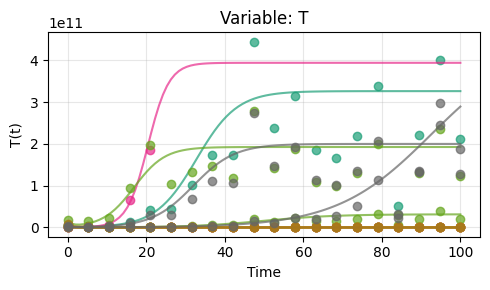

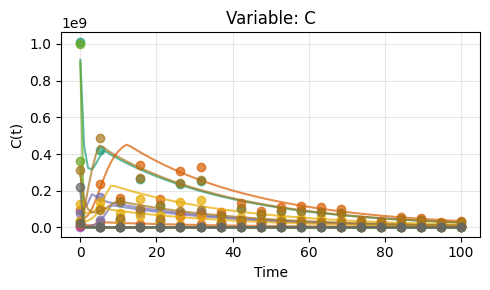

In [ ]:
n = 15
n_obs = 20
n_obs_vars = 4
noise_level = 0.35
scheduler_funcs = [uniform_scheduler(0, 100) for _ in range(n)]
noise_funcs = [proportional_normal_noise(noise_level, 0) for _ in range(n_obs_vars)]

seed = n + 3
plot_trajectories(
    n_indivs=n,
    n_obs=n_obs,
    param_sampler_func=param_sampler,
    initial_conditions_func=initial_conds_sampler,
    schedulers=scheduler_funcs,
    curve_schedulers=scheduler_funcs,
    noise_funcs=noise_funcs,
    seed=seed,
)